In [157]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve, roc_auc_score)
import matplotlib.pyplot as plt

In [158]:
data = pd.DataFrame({
    "shoe_size_eu": [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 38, 39, 39, 42, 42],
    "gender":       ["F","F","F","F","F","F","M","M","M","M","F","M","M","M","F"]
})

In [159]:
x = data[["shoe_size_eu"]].values
y = data["gender"].values

In [160]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=4, stratify=y)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)
predictions_proba = knn.predict_proba(x_test) # Predict probability instead of values
predictions = knn.predict(x_test)
print(predictions_proba)
print(predictions)

[[0.66666667 0.33333333]
 [0.33333333 0.66666667]
 [0.33333333 0.66666667]
 [0.66666667 0.33333333]
 [0.66666667 0.33333333]
 [0.33333333 0.66666667]
 [0.66666667 0.33333333]
 [0.33333333 0.66666667]]
['F' 'M' 'M' 'F' 'F' 'M' 'F' 'M']


In [161]:
print("Predikcija", predictions)
print("Istina\t  ", y_test)
print("Match\t  ", np.equal(predictions, y_test).astype(int))

Predikcija ['F' 'M' 'M' 'F' 'F' 'M' 'F' 'M']
Istina	   ['M' 'M' 'F' 'F' 'F' 'M' 'F' 'M']
Match	   [0 1 0 1 1 1 1 1]


In [162]:
labels = ["M", "F"]

In [163]:
print("Accuracy", accuracy_score(y_test, predictions))
print("Precision", precision_score(y_test, predictions, pos_label="M"))
print("Recall", recall_score(y_test, predictions, pos_label="M"))
print("F1", f1_score(y_test, predictions, pos_label="M"))
print("Confusion matrix\n", confusion_matrix(y_test, predictions, labels=labels))

Accuracy 0.75
Precision 0.75
Recall 0.75
F1 0.75
Confusion matrix
 [[3 1]
 [1 3]]


In [164]:
y_pred_stat = predictions_proba[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_stat, pos_label="M")
roc_matrix = np.column_stack((tpr, fpr, thresholds))
print(roc_matrix)

[[0.         0.                inf]
 [0.75       0.25       0.66666667]
 [1.         1.         0.33333333]]


In [165]:
target_recall = 0.3
idx = np.where(tpr >= target_recall)[0]
thr_for_recall = thresholds[idx[0]] if len(idx) > 0 else 0.5
print(thr_for_recall)

0.6666666666666666


In [166]:
y_pred_custom = (y_pred_stat >= 0.3).astype(int)
print(y_pred_custom)
print(np.where(y_test == "M", 1, 0))

[1 1 1 1 1 1 1 1]
[1 1 0 0 0 1 0 1]


    FPR   TPR  Threshold
0  0.00  0.00        inf
1  0.25  0.75   0.666667
2  1.00  1.00   0.333333


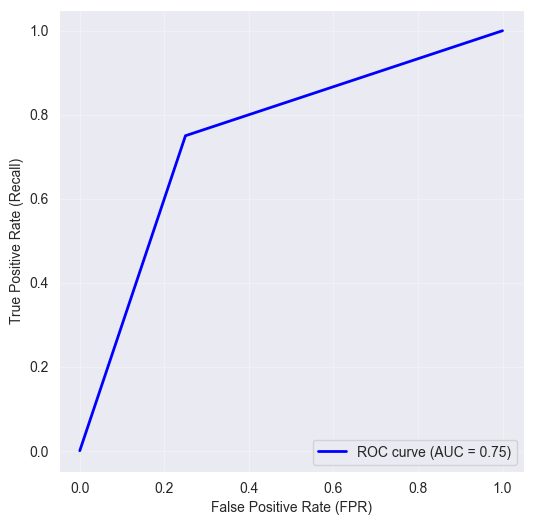

In [167]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_stat, pos_label='M')
roc_auc = roc_auc_score(y_test, y_pred_stat)
roc_df = pd.DataFrame({
    "FPR": fpr,
    "TPR": tpr,
    "Threshold": thresholds
})
print(roc_df.head(20))  # ispis prvih 10 redova
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (Recall)")
#plt.title("ROC krivulja")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()